### Anti-Money Laundering Risk Flagging Using Machine Learning

**Prepared By: Olumide Johnson Ikumapayi**

**Project Summary**

Money laundering remains a significant threat to global financial systems. Traditional rule-based AML systems often fail to adapt to the ever-evolving tactics of fraudsters. This project aims to build an intelligent machine learning model that can flag transactions with a high likelihood of involvement in money laundering by learning from patterns in transactional behavior. By using synthetic mobile money transaction data that replicates real-world complexity, the project helps financial auditors and institutions automate surveillance, reduce false positives, and improve regulatory compliance.


**Key Goals**:To detect suspicious transactions that may indicate money laundering, minimize false positives through accurate risk flagging, support real-time or batch processing for AML compliance teams and demonstrate effectiveness using classification models and anomaly detection techniques.


**About the Dataset**:

This dataset includes mobile money transaction records, simulating behaviors such as account transfers, merchant payments, bill payments, and cash-outs. Some transactions are labeled as **fraudulent**, while others are **non-fraudulent/legitimate**. The dataset supports classification tasks by providing both transactional attributes and fraud labels.Here is the link to the dataset on Kaggle public repository:https://www.kaggle.com/datasets/sriharshaeedala/financial-fraud-detection-dataset


**Please Note** - The target variable (isFraud) is binary in nature, hence the transactions are either classified as **fraudulent (1)** or **non-fraudulent (0)**. Therefore, this is a binary classification problem.

The flow of the **Anti-Money Laundering Risk Flagging** dataset is as follows:

1. [Importing libraries](#Importing-libraries)
2. [Data Acquisition & Initial Inspection](#Data-Acquisition-&-Initial-Inspection)
3. [Data Cleaning & Missing Values](#Data-Cleaning-&-Missing-Values)
4. [Description of the Dataset](#Description-of-the-Dataset)
5. [Exploratory Data Analysis (EDA)](#Exploratory-Data-Analysis-(EDA))
6. [Correlation Analysis](#Correlation-Analysis)
7. [Feature Engineering & Preprocessing](#Feature-Engineering-&-Preprocessing)
8. [Handling imbalanced target variable Using SMOTE](#Handling-imbalanced-target-variable-Using-SMOTE)
9. [Machine Learning Model Evaluation](#Machine-Learning-Model-Evaluation)
10.[Summary and Conclusion](#Summary-and-Conclusion)

### Project Setup & Libraries

In [1]:
# Standard Library
import warnings
warnings.filterwarnings('ignore')

# Data Handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Feature Engineering
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Model Selection
from sklearn.model_selection import train_test_split

# Handling Imbalanced Data
from imblearn.over_sampling import SMOTE

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# Pipeline
from sklearn.pipeline import Pipeline

# Statistical Tools
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay,
    plot_roc_curve
)

### Data Acquisition & Initial Inspection

**Loading data from the database**

In [2]:
df_Synthetic_Financial_datasets = pd.read_csv('Synthetic_Financial_datasets_log.csv')
df_Synthetic_Financial_datasets.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
df_Synthetic_Financial_datasets.tail()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0
6362619,743,CASH_OUT,850002.52,C1280323807,850002.52,0.0,C873221189,6510099.11,7360101.63,1,0


**Inspecting shape, column, types, missing values and Other Basic Statistics**

In [4]:
# Checking the dataset dimension
df_Synthetic_Financial_datasets.shape

(6362620, 11)

The dataset contains 6,362,620 rows and 11 columns.Of which 1 is target variable and the remaining 10 are independent variables.

In [5]:
# Check column of the dataset
df_Synthetic_Financial_datasets.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [6]:
# Checking the list of columns for dataset
df_Synthetic_Financial_datasets.columns.tolist()

['step',
 'type',
 'amount',
 'nameOrig',
 'oldbalanceOrg',
 'newbalanceOrig',
 'nameDest',
 'oldbalanceDest',
 'newbalanceDest',
 'isFraud',
 'isFlaggedFraud']

**Attribute Information**

**Input Variables (Features)**:    

* **step**: Time step unit (e.g., hour) when the transaction occurred
* **type**:   Type of transaction (TRANSFER, CASH_OUT, DEBIT, etc.)
* **amount**: Monetary value of the transaction
* **nameOrig**: ID of the sender
* **oldbalanceOrg**: Sender’s balance before the transaction
* **newbalanceOrig**:Sender’s balance after the transaction
* **nameDest**:ID of the recipient
* **oldbalanceDest**:Recipient’s balance before the transaction
* **newbalanceDest**:Recipient’s balance after the transaction
* **isFlaggedFraud**:Manually flagged suspicious transaction (binary)

**Output Variable(Target)**:

* **isFraud**: (1) if the transaction is fraudulent (suspected laundering); 0 otherwise

In [7]:
# checking the types of columns
df_Synthetic_Financial_datasets.dtypes

step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

There three(3) different types of data(int64, object and float64) present in the dataset.

In [8]:
# Checking the column info
df_Synthetic_Financial_datasets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


The dataset contains over 6.3 million financial transactions with 11 variables, combining transaction attributes, account balance information, and fraud indicators.

In [9]:
# Lets Separate the numerical from categorical columns

# check out the categorical columns
categorical_col = []
for i in df_Synthetic_Financial_datasets.dtypes.index:
    if df_Synthetic_Financial_datasets.dtypes[i] == "object":
        categorical_col.append(i)
print("categorical columns:", categorical_col)
print("\n")

# Check for Numerical column
numerical_col = []
for i in df_Synthetic_Financial_datasets.dtypes.index:
    if df_Synthetic_Financial_datasets.dtypes[i]!= "object":
        numerical_col.append(i)
print("numerical columns:", numerical_col)

categorical columns: ['type', 'nameOrig', 'nameDest']


numerical columns: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']


### Data Cleaning & Missing Values

**Handling null, missing and inconsistent data**

In [10]:
# checking null values
df_Synthetic_Financial_datasets.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [11]:
# The total Number of missing values in the dataset
df_Synthetic_Financial_datasets.isnull().sum().sum()

0

<AxesSubplot:>

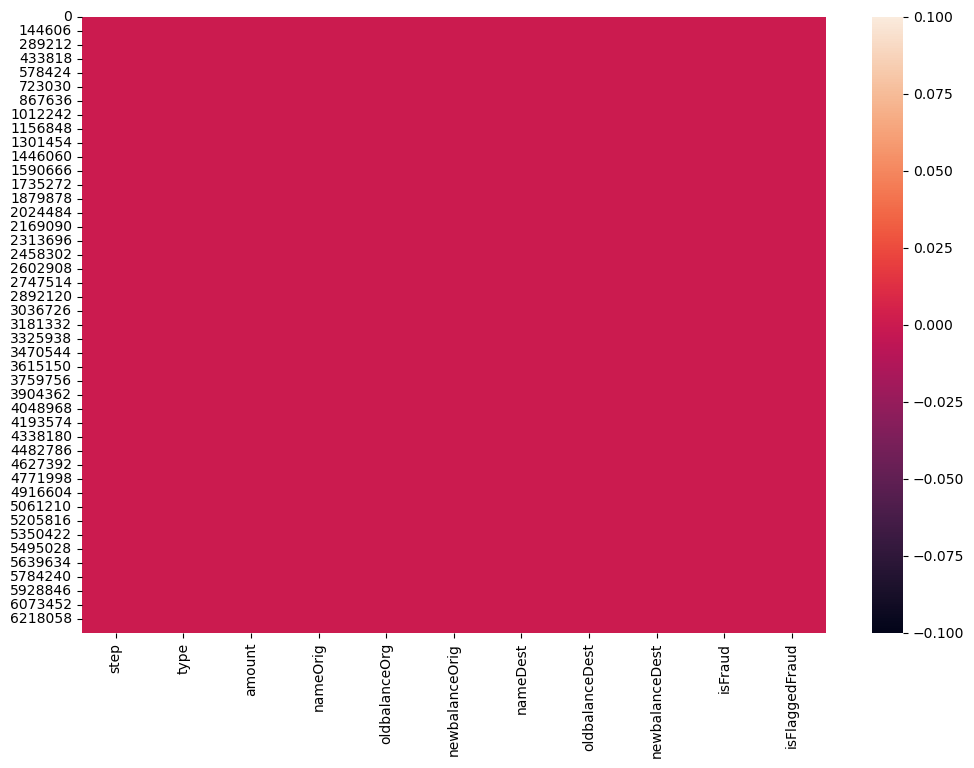

In [12]:
# Lets Visualize using heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df_Synthetic_Financial_datasets.isnull())

The heatmap shows no missing values across all 11 variables and more than 6.3 million records, indicating that the dataset is fully complete and ready for analysis.

In [13]:
# Checking the unique values of objects-column
for col in df_Synthetic_Financial_datasets.select_dtypes(include='object').columns:
    print(col)
    print(df_Synthetic_Financial_datasets[col].unique())

type
['PAYMENT' 'TRANSFER' 'CASH_OUT' 'DEBIT' 'CASH_IN']
nameOrig
['C1231006815' 'C1666544295' 'C1305486145' ... 'C1162922333' 'C1685995037'
 'C1280323807']
nameDest
['M1979787155' 'M2044282225' 'C553264065' ... 'C1850423904' 'C1881841831'
 'C2080388513']


In [14]:
# Finding number of unique values in the column
df_Synthetic_Financial_datasets.nunique().to_frame("No.of unique values")

,No.of unique values
step,743
type,5
amount,5316900
nameOrig,6353307
oldbalanceOrg,1845844
newbalanceOrig,2682586
nameDest,2722362
oldbalanceDest,3614697
newbalanceDest,3555499
isFraud,2


All the features have more than one single values.

In [15]:
# Lets take a look at the 1st few heads again
df_Synthetic_Financial_datasets.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [16]:
# Checking the list of counts of target
df_Synthetic_Financial_datasets["isFraud"].unique()

array([0, 1], dtype=int64)

There are two categories present in the target column namely "0" and "1"

In [17]:
# Checking the unique values in target column
df_Synthetic_Financial_datasets['isFraud'].value_counts()

0    6354407
1       8213
Name: isFraud, dtype: int64

We assume that "1" stands for Fraudulent and "0" for Non-Fraudulent/Legitimate.

### Data Description

In [18]:
# Statistical summary of numerical columns
df_Synthetic_Financial_datasets.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [19]:
# Lets also check the statistical distribution for numerical features
df_Synthetic_Financial_datasets.describe().T

,count,mean,std,min,25%,50%,75%,max
step,6362620.0,2.433972e+02,1.423320e+02,1.0,156.00,239.000,3.350000e+02,7.430000e+02
amount,6362620.0,1.798619e+05,6.038582e+05,0.0,13389.57,74871.940,2.087215e+05,9.244552e+07
oldbalanceOrg,6362620.0,8.338831e+05,2.888243e+06,0.0,0.00,14208.000,1.073152e+05,5.958504e+07
newbalanceOrig,6362620.0,8.551137e+05,2.924049e+06,0.0,0.00,0.000,1.442584e+05,4.958504e+07
oldbalanceDest,6362620.0,1.100702e+06,3.399180e+06,0.0,0.00,132705.665,9.430367e+05,3.560159e+08
newbalanceDest,6362620.0,1.224996e+06,3.674129e+06,0.0,0.00,214661.440,1.111909e+06,3.561793e+08
isFraud,6362620.0,1.290820e-03,3.590480e-02,0.0,0.00,0.000,0.000000e+00,1.000000e+00
isFlaggedFraud,6362620.0,2.514687e-06,1.585775e-03,0.0,0.00,0.000,0.000000e+00,1.000000e+00


### Exploratory Data Analysis (EDA)

**Univariate Analysis**

In [20]:
# The number of Fraud
print(df_Synthetic_Financial_datasets['isFraud'].value_counts())

0    6354407
1       8213
Name: isFraud, dtype: int64


In [21]:
# The % rate of Fraud
target_df=df_Synthetic_Financial_datasets['isFraud'].value_counts()*100/df_Synthetic_Financial_datasets.shape[0]
target_df

0    99.870918
1     0.129082
Name: isFraud, dtype: float64

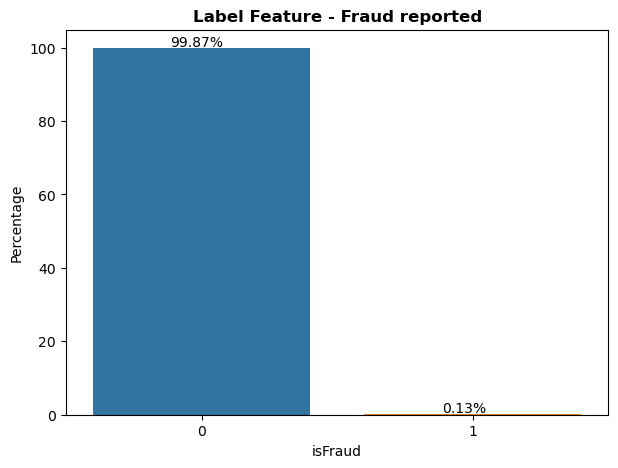

In [22]:
plt.figure(figsize=(7,5))
plt.title("Label Feature - Fraud reported",fontdict={'fontweight':'bold','fontsize':12})
ax=sns.barplot(x=target_df.index,y=target_df.values)
plt.xlabel('isFraud')
plt.ylabel('Percentage')

for p in ax.patches:
    height=p.get_height()
    width=p.get_width()
    x,_=p.get_xy()
    ax.text(x+width/2.8,height+0.5,f'{height:.2f}%')

The above target distribution is **highly imbalanced**, with **99.87%** of transactions classified as **non-fraud (0)** and only **0.13%** classified as **fraud (1)**. This shows that fraudulent transactions are extremely rare in the dataset, which is typical in real-world financial data.Therefore, for this project, it means fraud detection models will need careful handling of class imbalance to avoid biased predictions toward the majority class.


**Histogram Plots for each Feature variables**

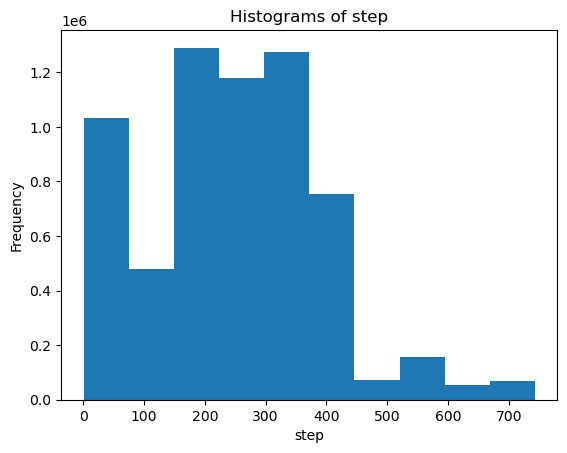

In [23]:
# Histogram for step
plt.hist(df_Synthetic_Financial_datasets['step'])
plt.xlabel("step")
plt.ylabel("Frequency")
plt.title('Histograms of step')
plt.show()

The above **step** variable is concentrated mainly in the lower to middle ranges, with the highest transaction frequencies occurring roughly between **150 and 350**. After this range, the frequency declines noticeably, especially beyond **450**, indicating that fewer transactions occur in the later time steps. This suggests that transaction activity is more intense during the earlier and middle periods captured in the dataset.


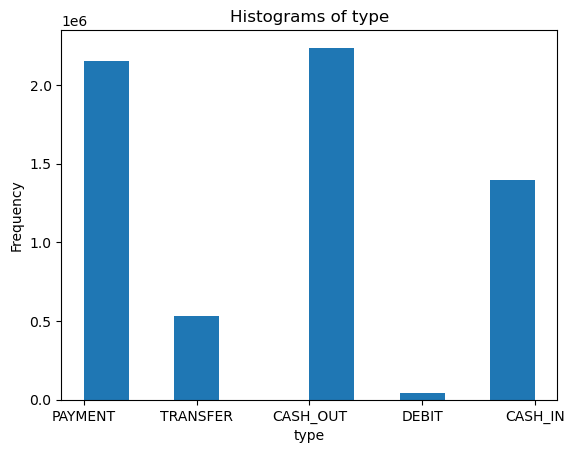

In [24]:
# Histogram for type
plt.hist(df_Synthetic_Financial_datasets['type'])
plt.xlabel("type")
plt.ylabel("Frequency")
plt.title('Histograms of type')
plt.show()

Transaction types are unevenly distributed, with **CASH_OUT** and **PAYMENT** appearing most frequently, each accounting for over **2 million** records. **CASH_IN** also represents a substantial share at around **1.4 million**, while **TRANSFER** is much lower at roughly **500 Thousand**, and **DEBIT** is the least common with only a very small proportion of transactions. 

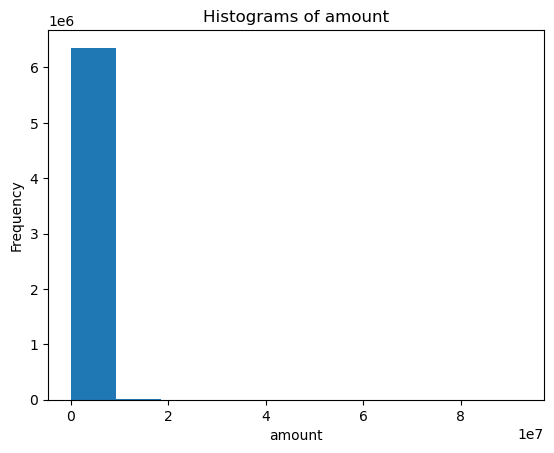

In [25]:
# Histogram for amount
plt.hist(df_Synthetic_Financial_datasets['amount'])
plt.xlabel("amount")
plt.ylabel("Frequency")
plt.title('Histograms of amount')
plt.show()

The **amount** variable is **highly right-skewed**, with the vast majority of transactions concentrated at lower values and only a small number of very large transactions stretching the distribution. 

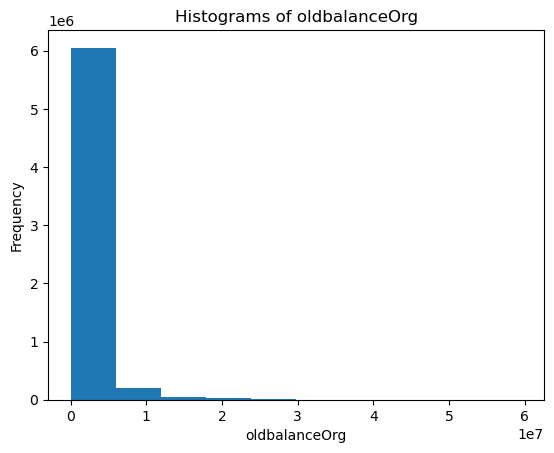

In [26]:
# Histogram for oldbalanceOrg
plt.hist(df_Synthetic_Financial_datasets['oldbalanceOrg'])
plt.xlabel("oldbalanceOrg")
plt.ylabel("Frequency")
plt.title('Histograms of oldbalanceOrg')
plt.show()

The **oldbalanceOrg** variable is heavily concentrated at lower values, with most origin account balances clustered near zero and only a small number of accounts showing very high balances. This creates a strongly right-skewed distribution, suggesting that accounts with low-balance dominate the dataset while those with high-balance are relatively rare.


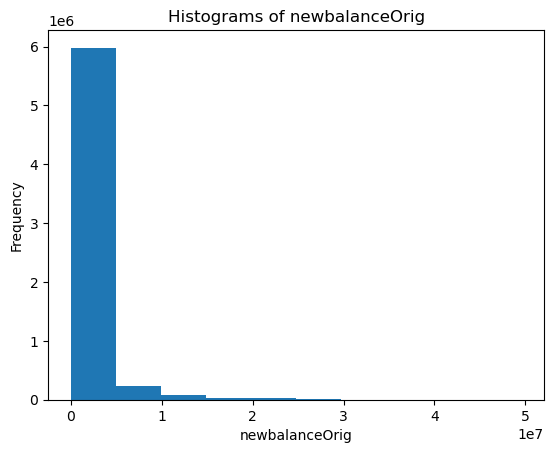

In [27]:
# Histogram for newbalanceOrig
plt.hist(df_Synthetic_Financial_datasets['newbalanceOrig'])
plt.xlabel("newbalanceOrig")
plt.ylabel("Frequency")
plt.title('Histograms of newbalanceOrig')
plt.show()

The **newbalanceOrig** variable is also heavily concentrated at lower values, with most post-transaction origin account balances remaining close to zero and only a small number reaching very high levels. 


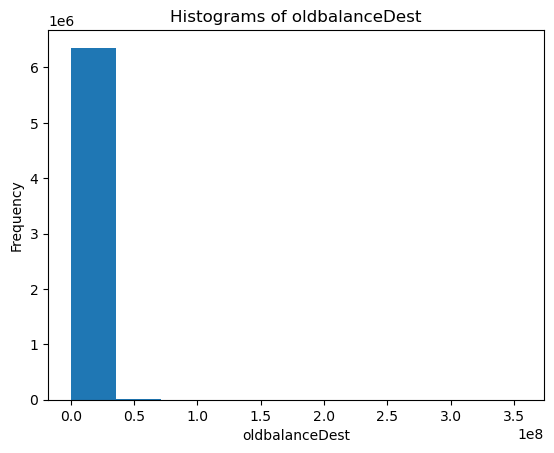

In [28]:
# Histogram for oldbalanceDest 
plt.hist(df_Synthetic_Financial_datasets['oldbalanceDest'])
plt.xlabel("oldbalanceDest")
plt.ylabel("Frequency")
plt.title('Histograms of oldbalanceDest')
plt.show()

The **oldbalanceDest** variable is highly concentrated at lower values, with most destination account balances clustered near zero and only a very small number extending to extremely high values. 

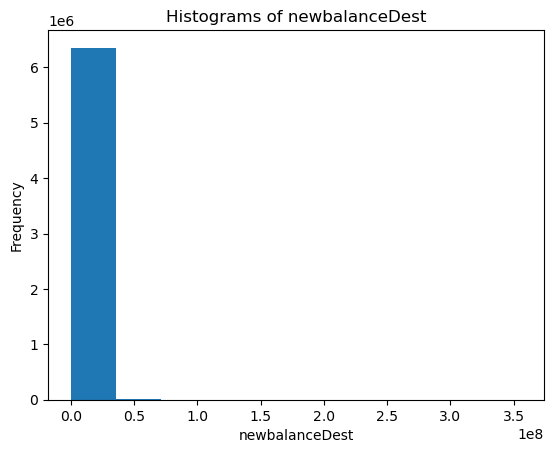

In [29]:
# Histogram for newbalanceDest 
plt.hist(df_Synthetic_Financial_datasets['newbalanceDest'])
plt.xlabel("newbalanceDest")
plt.ylabel("Frequency")
plt.title('Histograms of newbalanceDest')
plt.show()

The **newbalanceDest** variable is similarly concentrated at lower values, with most post-transaction destination balances remaining close to zero and only a few cases reaching very high amounts. 

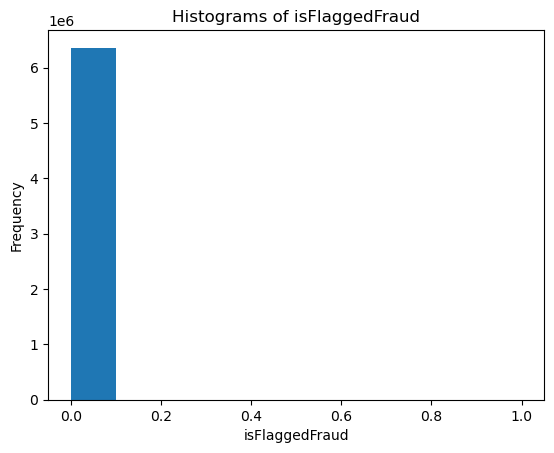

In [30]:
# Histogram for isFlaggedFraud 
plt.hist(df_Synthetic_Financial_datasets['isFlaggedFraud'])
plt.xlabel("isFlaggedFraud")
plt.ylabel("Frequency")
plt.title('Histograms of isFlaggedFraud')
plt.show()

The **isFlaggedFraud** variable is extremely concentrated at **0**, with almost all transactions not flagged and only a negligible number marked as **1**. This indicates that flagged fraud cases are very rare in the dataset, suggesting that this feature is highly imbalanced and may offer limited variation for analysis on its own.


**Visualizing Count plots**

CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: type, dtype: int64


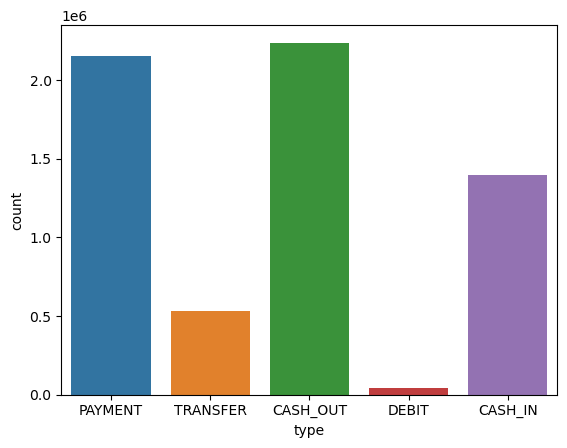

In [31]:
# Visualizing the count of type
print(df_Synthetic_Financial_datasets['type'].value_counts())
ax = sns.countplot(x='type', data= df_Synthetic_Financial_datasets)
plt.show()

The transaction type distribution shows that **2,237,500** transactions were **CASH_OUT**, while **2,151,495** were **PAYMENT** transactions. In addition, **1,399,284** transactions were **CASH_IN**, whereas **TRANSFER** was much lower at **532,909**, and **DEBIT** was the least frequent with only **41,432** transactions.

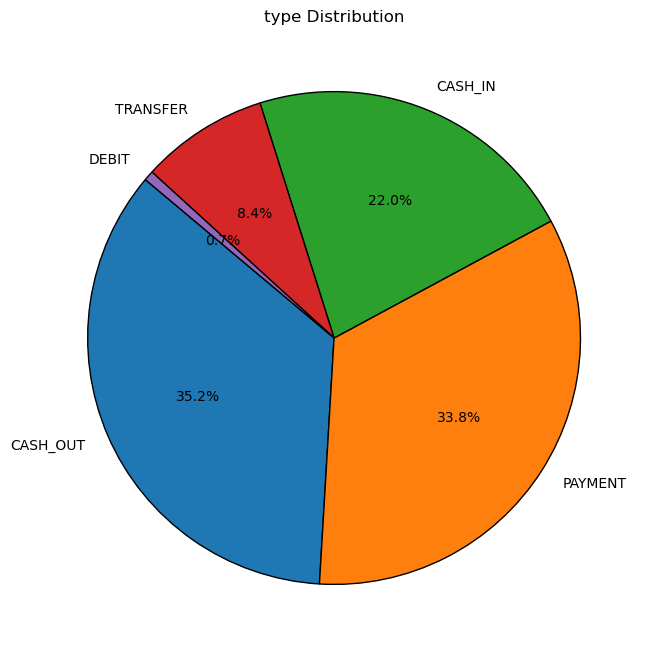

In [32]:
# Count of type
mode_counts = df_Synthetic_Financial_datasets["type"].value_counts()

# Pie chart
plt.figure(figsize=(8,8))
plt.pie(
    mode_counts.values,
    labels=mode_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    wedgeprops={"edgecolor": "black"}
)

plt.title("type Distribution")
plt.show()

The pie chart shows that **35.2%** of the transactions were **CASH_OUT**, representing the largest share, followed by **PAYMENT** at **33.8%** and **CASH_IN** at **22.0%**. **TRANSFER** accounts for a much smaller portion at **8.4%**, while **DEBIT** contributes only **0.7%**. In all, the majority of transactions were carried out through the **CASH_OUT** and **PAYMENT** channels.

**Checking The Skewness and Normality**

In [33]:
# Lets have a look at the skewness
df_Synthetic_Financial_datasets.skew()

step                0.375177
amount             30.993949
oldbalanceOrg       5.249136
newbalanceOrig      5.176884
oldbalanceDest     19.921758
newbalanceDest     19.352302
isFraud            27.779538
isFlaggedFraud    630.603629
dtype: float64

**Removing The Skewness**

In [34]:
# Removing skewness using the cuberoot method
df_Synthetic_Financial_datasets['amount'] = np .cbrt(df_Synthetic_Financial_datasets['amount'])
df_Synthetic_Financial_datasets['oldbalanceDest'] = np .cbrt(df_Synthetic_Financial_datasets['oldbalanceDest'])
df_Synthetic_Financial_datasets['newbalanceDest'] = np .cbrt(df_Synthetic_Financial_datasets['newbalanceDest'])

In [35]:
# Let us Check the skewness once again
df_Synthetic_Financial_datasets.skew()

step                0.375177
amount              1.364136
oldbalanceOrg       5.249136
newbalanceOrig      5.176884
oldbalanceDest      0.988329
newbalanceDest      0.893305
isFraud            27.779538
isFlaggedFraud    630.603629
dtype: float64

We have reduced the level of skewness

**Visualizing the data distribution in the columns after removing the skewness**.

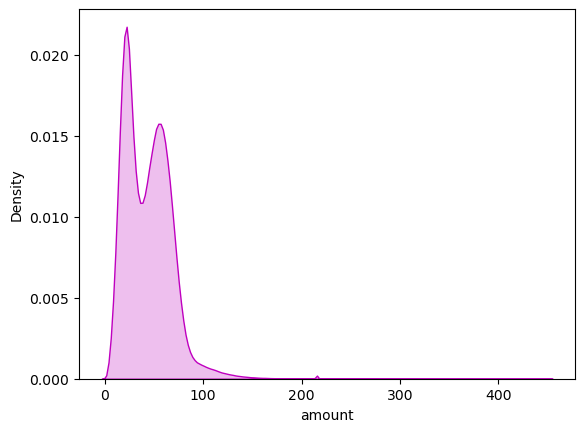

In [36]:
# Data distribution in the amount after skewness
sns.distplot(df_Synthetic_Financial_datasets['amount'], color = "m", kde_kws = {"shade":True}, hist = False)
plt.show()

The distribution of **transaction amount** is positively(+vely) skewed, with most transactions concentrated at lower values and only a few occurring at much higher amounts. The density is highest in the lower range, indicating that small-value transactions are more common, while large transactions are relatively rare. This pattern suggests that unusual high-value transactions may stand out more clearly in fraud analysis.


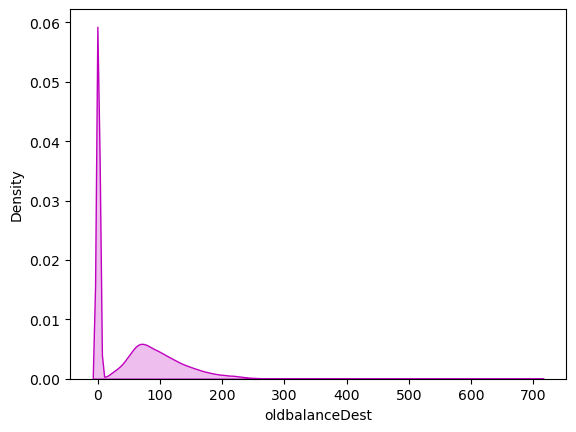

In [37]:
# Data distribution in the oldbalanceDest after skewness
sns.distplot(df_Synthetic_Financial_datasets['oldbalanceDest'], color = "m", kde_kws = {"shade":True}, hist = False)
plt.show()

The distribution of **oldbalanceDest** is highly right-skewed, with a very large concentration of values near zero and a smaller spread of transactions at higher balance levels. This suggests that most destination accounts start with low balances, while only a limited number hold relatively large amounts.

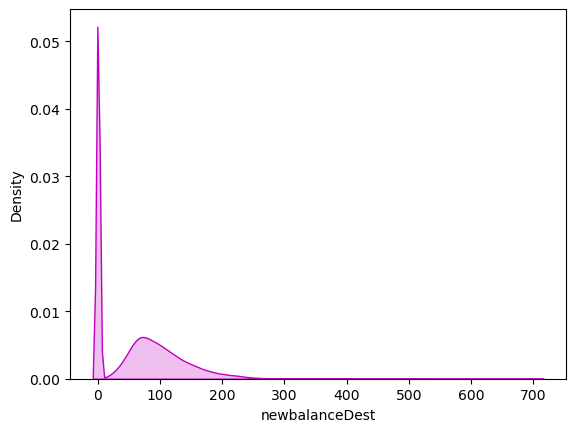

In [38]:
# Data distribution in the newbalanceDest after skewness
sns.distplot(df_Synthetic_Financial_datasets['newbalanceDest'], color = "m", kde_kws = {"shade":True}, hist = False)
plt.show()

The distribution of **newbalanceDest** is also strongly right-skewed, with most values clustered near zero and a smaller number extending to higher balances. This indicates that most destination accounts retain low post-transaction balances, while relatively few hold large amounts.

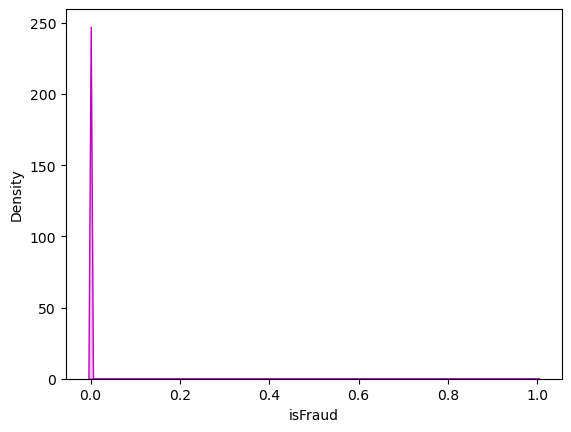

In [39]:
# Data distribution in the isFraud after skewness
sns.distplot(df_Synthetic_Financial_datasets['isFraud'], color = "m", kde_kws = {"shade":True}, hist = False)
plt.show()

The distribution of **isFraud** is extremely imbalanced, with the density concentrated almost entirely at **0** and only a very small proportion at **1**. This indicates that fraudulent transactions are rare in the dataset, while non-fraudulent transactions make up the overwhelming majority.This kind of pattern is important for fraud analysis because it highlights the need to address class imbalance during modeling.


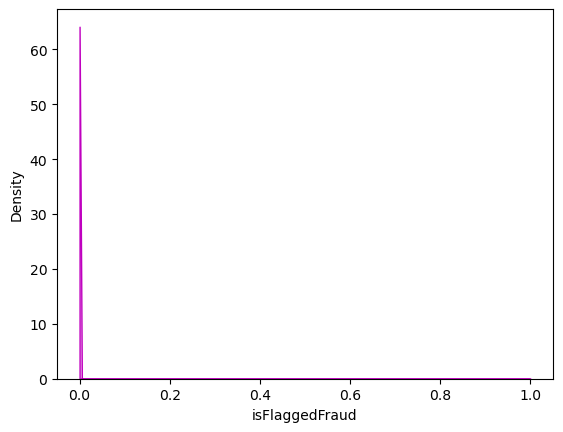

In [40]:
# Data distribution in the isFraud after skewness
sns.distplot(df_Synthetic_Financial_datasets['isFlaggedFraud'], color = "m", kde_kws = {"shade":True}, hist = False)
plt.show()

The above distribution of **isFlaggedFraud** is highly imbalanced, with almost all observations concentrated at **0** and only a negligible number at **1**. This shows that flagged fraud cases are extremely rare in the dataset, while the vast majority of transactions were not flagged.


**Bivariate Analysis**

<AxesSubplot:title={'center':'type in relation with Target(isFraud)'}, xlabel='type', ylabel='isFraud'>

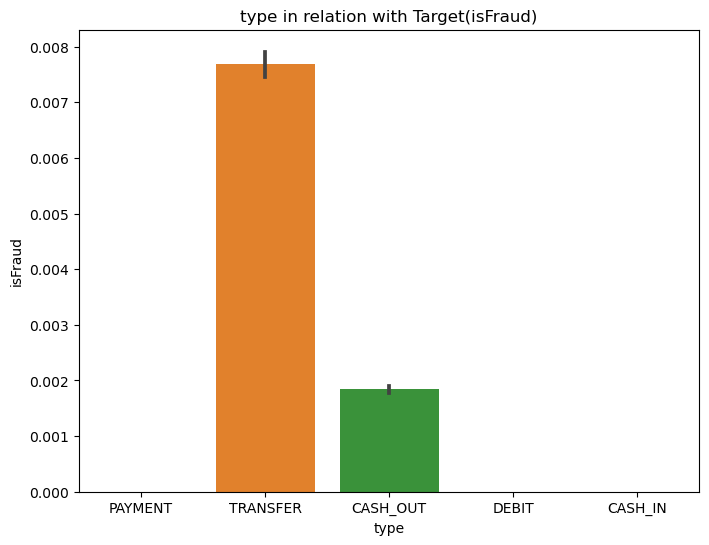

In [41]:
# barplot for type in relation to the target
fig = plt.figure(figsize = (8,6))
plt.title("type in relation with Target(isFraud)")
sns.barplot(x = 'type', y = 'isFraud', data = df_Synthetic_Financial_datasets)

This chart shows that fraud is concentrated almost entirely in **TRANSFER** and **CASH_OUT** transactions. **TRANSFER** has the highest fraud rate at about **0.0077** or **0.77%**, followed by **CASH_OUT** at roughly **0.0018** or **0.18%**, while **PAYMENT**, **DEBIT**, and **CASH_IN** show virtually no fraud. This suggests that transaction type is an important indicator in the dataset, with **TRANSFER** and **CASH_OUT** being the most fraud-prone channels.


<AxesSubplot:title={'center':'isFlaggedFraud  in relation with Target(isFraud)'}, xlabel='isFlaggedFraud', ylabel='isFraud'>

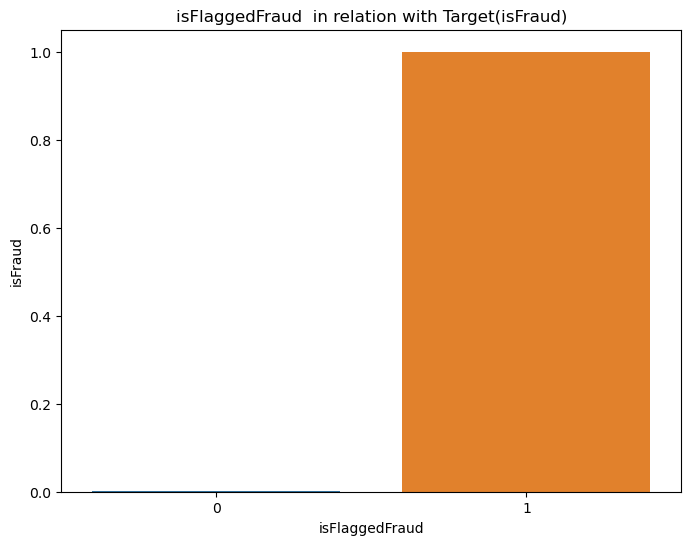

In [42]:
# barplot for isFlaggedFraud in relation to the target
fig = plt.figure(figsize = (8,6))
plt.title("isFlaggedFraud  in relation with Target(isFraud)")
sns.barplot(x = 'isFlaggedFraud', y = 'isFraud', data = df_Synthetic_Financial_datasets)

This chart shows a very strong relationship between **isFlaggedFraud** and **isFraud**. Transactions with **isFlaggedFraud = 1** are entirely associated with fraud, while those with **isFlaggedFraud = 0** have an almost zero fraud rate. This indicates that **isFlaggedFraud** is a highly predictive feature, although its rarity means it applies to only a very small subset of transactions.


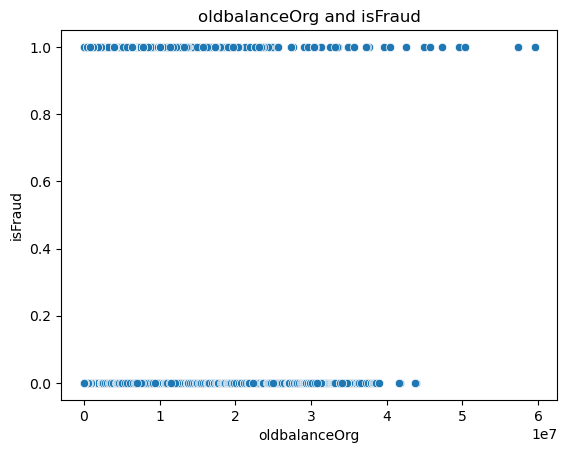

In [43]:
# Comparison between oldbalanceOrg and isFraud
plt.title("oldbalanceOrg and isFraud")
sns.scatterplot(x = "oldbalanceOrg", y = "isFraud", data = df_Synthetic_Financial_datasets)
plt.show()

This scatter plot suggests that **oldbalanceOrg** alone does not clearly separate fraudulent and non-fraudulent transactions, as both classes appear across a wide range of balance values. However, fraudulent cases seem to occur more often at higher origin balances, while non-fraud cases are more widely spread across both low and moderate balances.

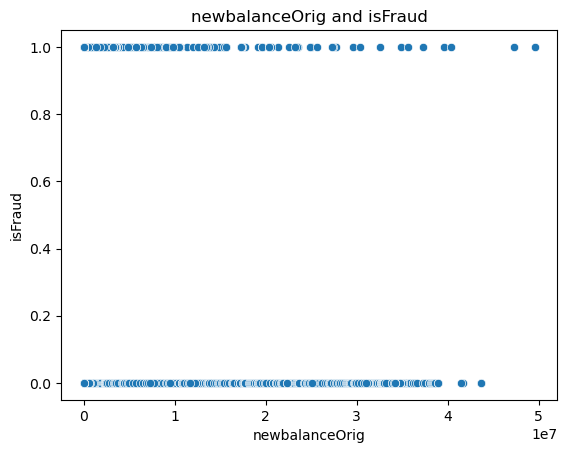

In [44]:
# Comparison between newbalanceOrig and isFraud
plt.title("newbalanceOrig and isFraud")
sns.scatterplot(x = "newbalanceOrig", y = "isFraud", data = df_Synthetic_Financial_datasets)
plt.show()

This scatter plot shows that **newbalanceOrig** does not clearly distinguish **fraudulent from non-fraudulent** transactions on its own, since both classes appear across a broad range of values. However, fraudulent transactions are more visible at relatively higher post-transaction origin balances, while non-fraud cases are spread more widely across the range.

### Correlation Analysis

In [45]:
# Checking the correlation between features and the target.
cor = df_Synthetic_Financial_datasets.corr()
cor

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
step,1.000000,0.009355,-0.010058,-0.010299,0.004812,0.003060,0.031578,0.003277
amount,0.009355,1.000000,0.072529,0.074901,0.523631,0.629765,0.065664,0.007344
oldbalanceOrg,-0.010058,0.072529,1.000000,0.998803,0.196989,0.138224,0.010154,0.003835
newbalanceOrig,-0.010299,0.074901,0.998803,1.000000,0.201261,0.137602,-0.008148,0.003776
oldbalanceDest,0.004812,0.523631,0.196989,0.201261,1.000000,0.950828,-0.015756,-0.001461
newbalanceDest,0.003060,0.629765,0.138224,0.137602,0.950828,1.000000,-0.003747,-0.001574
isFraud,0.031578,0.065664,0.010154,-0.008148,-0.015756,-0.003747,1.000000,0.044109
isFlaggedFraud,0.003277,0.007344,0.003835,0.003776,-0.001461,-0.001574,0.044109,1.000000


The above shows the correlation between the dependent and independent variables. We can visualize this using heatmap.

<AxesSubplot:>

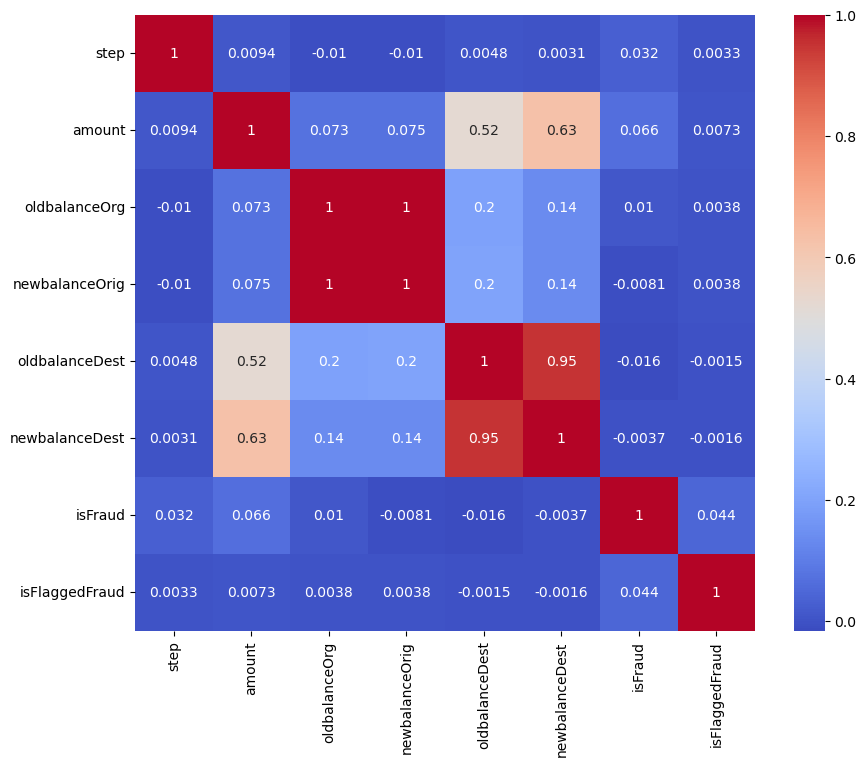

In [46]:
# Correlation Matrix Visualized
corr = df_Synthetic_Financial_datasets.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr,annot=True,cmap='coolwarm')

The correlation results show that most of the variables have only **very weak relationships** with **fraud**, suggesting that no single feature can explain fraudulent activity on its own.However, Stronger relationships are mainly observed among the balance variables, especially **oldbalanceOrg and newbalanceOrig**, and **oldbalanceDest and newbalanceDest**.

In [47]:
# Lets Show the correlation of variables in ascending order with the target
corr = df_Synthetic_Financial_datasets.corr()
corr['isFraud'].sort_values(ascending = False)

isFraud           1.000000
amount            0.065664
isFlaggedFraud    0.044109
step              0.031578
oldbalanceOrg     0.010154
newbalanceDest   -0.003747
newbalanceOrig   -0.008148
oldbalanceDest   -0.015756
Name: isFraud, dtype: float64

As shown, atleast three(3) features have negative(-ve) relationship with **isFraud**, these are **newbalanceDest, newbalanceOrig and oldbalanceDest**.They all have a negative correlation with the target.

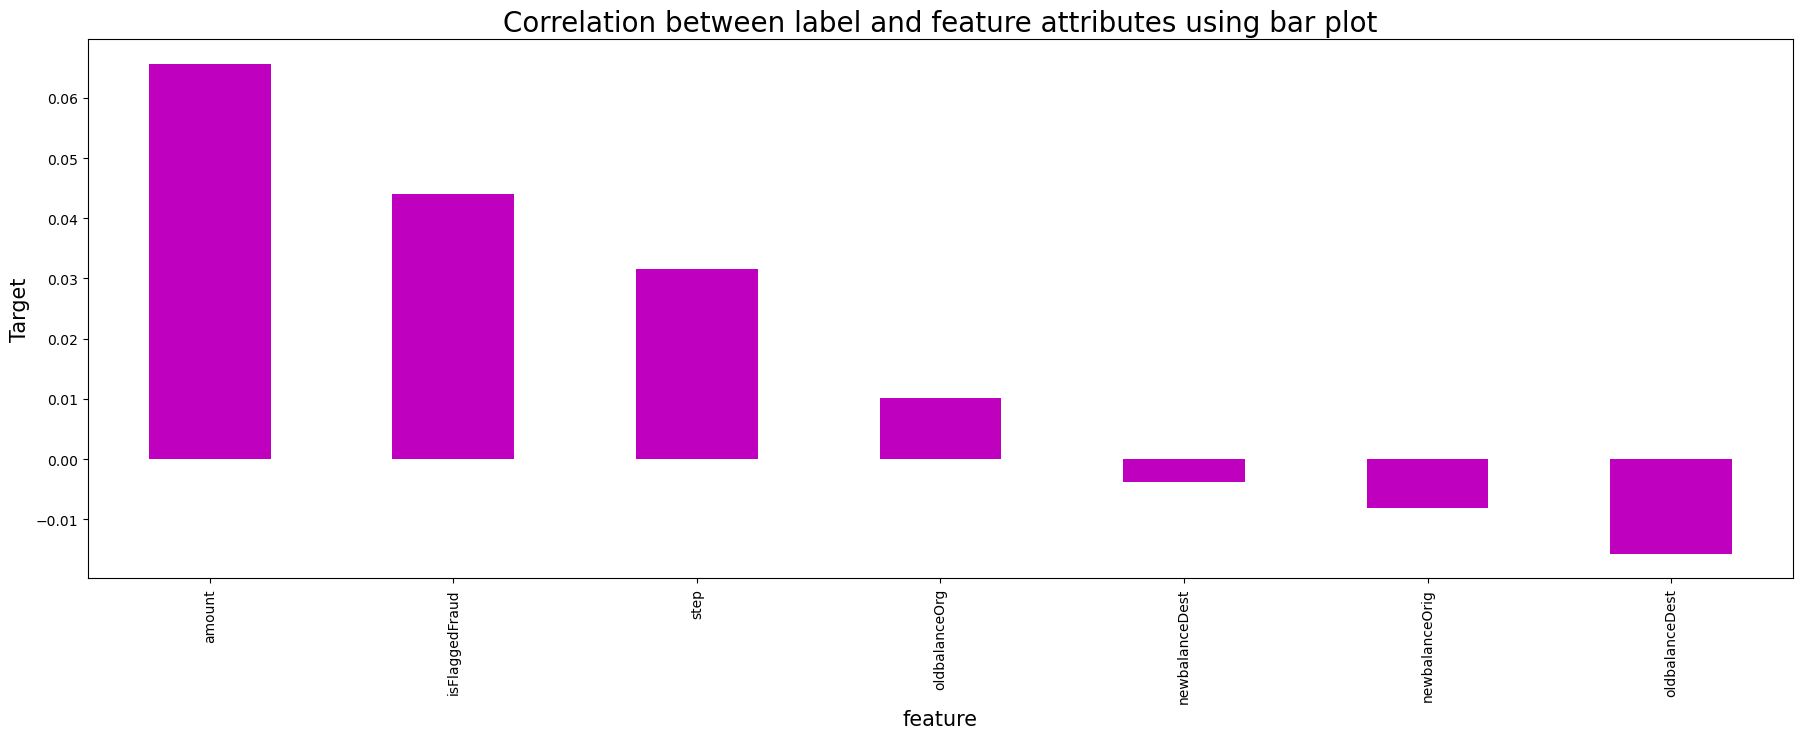

In [48]:
plt.figure(figsize = (22, 7))
df_Synthetic_Financial_datasets.corr()['isFraud'].sort_values(ascending = False).drop(['isFraud']).plot(kind='bar',color="m")
plt.xlabel('feature', fontsize = 15)
plt.ylabel('Target', fontsize = 15)
plt.title("Correlation between label and feature attributes using bar plot", fontsize=20)
plt.show()

The bar plot shows that **amount** has the strongest positive(+ve) relationship with **fraud**, followed by **isFlaggedFraud** and **step**, although all correlations remain weak overall. The balance-related features have near-zero or slightly negative(-ve) relationships, Indicating they contribute less directly to fraud on their own.


### Feature Engineering & Preprocessing

##### SPLITING THE VARIABLES INTO FEATURES(X) AND TARGET(Y)

In [49]:
x = df_Synthetic_Financial_datasets.drop("step", axis =1)
y = df_Synthetic_Financial_datasets["isFraud"]

**Feature Scaling using standard scalarization**

In [50]:
# Encode categorical columns
x_encoded = x.copy()
for col in x_encoded.select_dtypes(include=['object']).columns:
    x_encoded[col] = LabelEncoder().fit_transform(x_encoded[col])

In [51]:
# Scale the encoded data
scaler = StandardScaler()
x_scaled = pd.DataFrame(scaler.fit_transform(x_encoded), columns=x_encoded.columns)

x_scaled.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,0.952399,-0.919198,-1.318825,-0.229810,-0.237622,1.220490,-0.921135,-0.992293,-0.035951,-0.001586
1,0.952399,-1.295604,-0.538520,-0.281359,-0.285812,1.316232,-0.921135,-0.992293,-0.035951,-0.001586
2,1.693076,-1.570072,-1.185630,-0.288654,-0.292442,-0.408856,-0.921135,-0.992293,27.815483,-0.001586
3,-0.528954,-1.570072,1.445742,-0.288654,-0.292442,-0.472820,-0.477624,-0.992293,27.815483,-0.001586
4,0.952399,-0.867502,0.146834,-0.274329,-0.282221,0.109953,-0.921135,-0.992293,-0.035951,-0.001586


In [52]:
x_scaled.tail()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
6362615,-0.528954,1.075898,1.349554,-0.171108,-0.292442,-0.320647,-0.921135,0.111305,27.815483,-0.001586
6362616,1.693076,5.822917,-0.784815,1.896491,-0.292442,-0.647092,-0.921135,-0.992293,27.815483,-0.001586
6362617,-0.528954,5.822917,-1.440909,1.896491,-0.292442,-0.850659,-0.265309,1.941241,27.815483,-0.001586
6362618,1.693076,2.105671,-0.503661,0.005581,-0.292442,-0.568766,-0.921135,-0.992293,27.815483,-0.001586
6362619,-0.528954,2.105671,-1.230845,0.005581,-0.292442,-0.282350,2.071895,2.084379,27.815483,-0.001586


**Checking Variance Inflation Factor(VIF)**

In [53]:
print(x.dtypes)

type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object


In [54]:
x = x.select_dtypes(include=['int64','float64'])

In [55]:
x = x.replace([np.inf, -np.inf], np.nan)
x = x.dropna()

In [56]:
# Finding variance inflation factor in each scaled column i.e.x.shape[1] (1/(1-R2))
vif = pd.DataFrame()
vif["VIF values"] = [variance_inflation_factor(x.values, i)
              for i in range(len(x.columns))]
vif["features"] = x.columns

vif

,VIF values,features
0,3.786897,amount
1,622.684278,oldbalanceOrg
2,629.219442,newbalanceOrig
3,25.528889,oldbalanceDest
4,32.046463,newbalanceDest
5,1.203880,isFraud
6,1.002267,isFlaggedFraud


### Handling imbalanced target variable Using SMOTE

In [57]:
y.value_counts()

0    6354407
1       8213
Name: isFraud, dtype: int64

**Using SMOTE for Oversampling**

In [58]:
# Oversampling the data 
SM = SMOTE()
x1,y1 = SM.fit_resample(x, y)

In [59]:
# checking the value count of target column
y.value_counts()

0    6354407
1       8213
Name: isFraud, dtype: int64

In [60]:
sm = SMOTE(random_state=42) # In order to obtain same output 
x_res, y_res = sm.fit_resample(x, y)
y_res = pd.DataFrame(y_res)
print(y_res.value_counts())

isFraud
0          6354407
1          6354407
dtype: int64


The data is now balanced, lets proceed to building our Machine learning classification models .

### Machine Learning Model Evaluation

#### SPLITTING THE DATA INTO TRAIN AND TEST USING THE 70:30 RULE

In [61]:
x_train, x_test, y_train, y_test = train_test_split(x_res,y_res,test_size=0.3,random_state=42,
                                                    shuffle=True,stratify=y_res)

### Setting The Base Accuracy Score

In [62]:
# Baseline accuracy = proportion of the majority class
counts = df_Synthetic_Financial_datasets['isFraud'].value_counts()
baseline_acc = counts.max() / counts.sum() * 100
print(f"Baseline accuracy to beat: {baseline_acc:.2f}%")

Baseline accuracy to beat: 99.87%


**Locating the best random state**

**Logistic Regression**

In [63]:
lRe = LogisticRegression()

In [64]:
lRe.fit(x_train, y_train)

LogisticRegression()

Classification Report (LR):
               precision    recall  f1-score   support

           0       0.86      0.97      0.91   1906323
           1       0.96      0.84      0.90   1906322

    accuracy                           0.90   3812645
   macro avg       0.91      0.90      0.90   3812645
weighted avg       0.91      0.90      0.90   3812645

Confusion Matrix (LR):
 [[1843021   63302]
 [ 309182 1597140]]


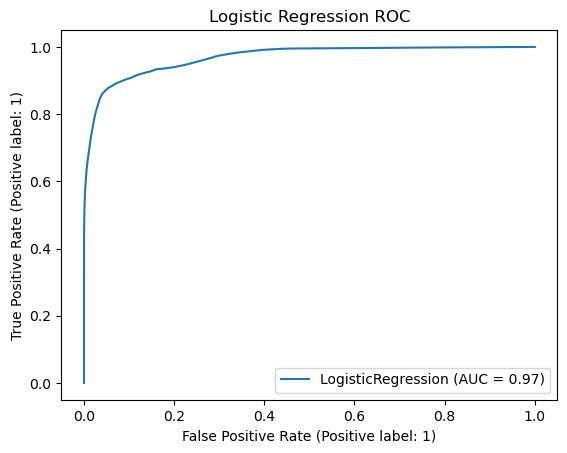

In [65]:
# y_test, X_test, logReg must exist (logReg is our trained LogisticRegression)
print("Classification Report (LR):\n", classification_report(y_test, lRe.predict(x_test)))
print("Confusion Matrix (LR):\n", confusion_matrix(y_test, lRe.predict(x_test)))

# ROC curve in one line
RocCurveDisplay.from_estimator(lRe, x_test, y_test)
plt.title("Logistic Regression ROC")
plt.show()

The logistic regression model performed well, with an **AUC of 0.97** and an overall **accuracy of 90%**. It correctly identified most non-fraud and fraud cases, although it missed **309,182** fraudulent transactions, showing that performance is strong but can still be improved for fraud detection.


**Random Forest**

In [66]:
RF = RandomForestClassifier()

In [67]:
RF.fit(x_train, y_train)

RandomForestClassifier()

Classification Report (RF):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906323
           1       1.00      1.00      1.00   1906322

    accuracy                           1.00   3812645
   macro avg       1.00      1.00      1.00   3812645
weighted avg       1.00      1.00      1.00   3812645

Confusion Matrix (RF):
 [[1906323       0]
 [      0 1906322]]


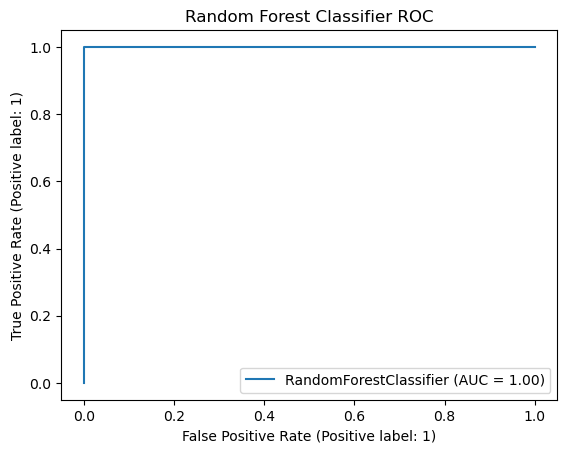

In [68]:
# y_test, X_test,while RanFor exists has our trained Random Forest Classifier
print("Classification Report (RF):\n", classification_report(y_test, RF.predict(x_test)))
print("Confusion Matrix (RF):\n", confusion_matrix(y_test, RF.predict(x_test)))

# ROC curve in one line
RocCurveDisplay.from_estimator(RF, x_test, y_test)
plt.title("Random Forest Classifier ROC")
plt.show()

The Random Forest model achieved **perfect performance**, with an **AUC of 1.00** and **100% accuracy**. It correctly classified all **1,906,323** non-fraud cases and all **1,906,322** fraud cases, with **no misclassifications** in the confusion matrix. This indicates extremely strong predictive performance.

**XGBoost(Extreme Gradient Boosting) Classifier**

In [69]:
XGboost = XGBClassifier()

In [70]:
XGboost.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              n_estimators=100, n_jobs=None, num_parallel_tree=None,
              predictor=None, random_state=None, ...)

Classification Report (XG):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906323
           1       1.00      1.00      1.00   1906322

    accuracy                           1.00   3812645
   macro avg       1.00      1.00      1.00   3812645
weighted avg       1.00      1.00      1.00   3812645

Confusion Matrix (XG):
 [[1906323       0]
 [      0 1906322]]


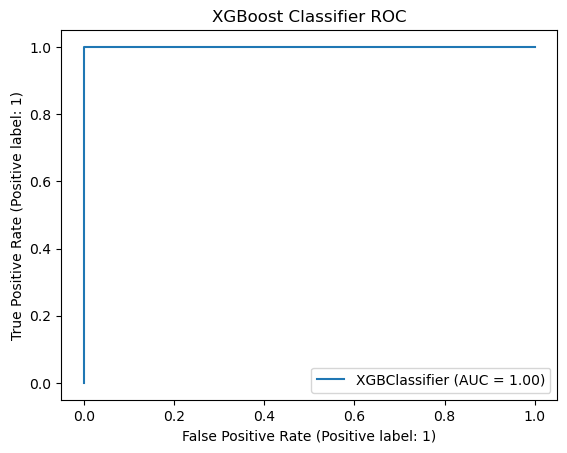

In [71]:
y_pred = XGboost.predict(x_test)

# y_test, X_test, while the XGb is our trained XGbClassifier)
print("Classification Report (XG):\n", classification_report(y_test, XGboost.predict(x_test)))
print("Confusion Matrix (XG):\n", confusion_matrix(y_test, XGboost.predict(x_test)))

# ROC curve in one line
RocCurveDisplay.from_estimator(XGboost, x_test, y_test)
plt.title("XGBoost Classifier ROC")
plt.show()

The XGBoost model also achieved **perfect performance**, with an **AUC of 1.00** and **100% accuracy**. It correctly classified all **1,906,323** non-fraud cases and all **1,906,322** fraud cases, with **no false positives or false negatives**. This also indicates exceptionally strong predictive performance.

### Predictions

In [72]:
# Saving the model using .pkl
import joblib
joblib.dump(XGboost, "AML (Anti-Money Laundering) Risk Flagging.pki")

['AML (Anti-Money Laundering) Risk Flagging.pki']

**Prediction On The Train Data**

In [73]:
modelname = XGBClassifier()

In [74]:
# Training the model on the training data
modelname.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              n_estimators=100, n_jobs=None, num_parallel_tree=None,
              predictor=None, random_state=None, ...)

In [75]:
# Lets load the saved model and get the predictions
XGboost = joblib.load("AML (Anti-Money Laundering) Risk Flagging.pki")

# prediction
prediction = XGboost.predict(x_train)
prediction

array([0, 1, 1, ..., 1, 0, 1])

In [76]:
a = np.array(y_train)
df_Synthetic_Financial_datasets_train = pd.DataFrame()
df_Synthetic_Financial_datasets_train["predicted"] = prediction
df_Synthetic_Financial_datasets_train["original"] = a
df_Synthetic_Financial_datasets_train

,predicted,original
0,0,0
1,1,1
2,1,1
3,1,1
4,1,1
...,...,...
8896164,1,1
8896165,0,0
8896166,1,1
8896167,0,0


**Prediction On The Test Data**

In [77]:
# Make predictions on the test data
predictions = modelname.predict(x_test)

In [78]:
# diagnostics
print("raw shapes:", np.shape(predictions), np.shape(y_test))

raw shapes: (3812645,) (3812645, 1)


In [79]:
# convert predictions -> 1D labels
pred_arr = np.asarray(predictions)
if pred_arr.ndim == 2:
    # if probabilities (two columns), take class with highest score
    if pred_arr.shape[1] == 1:
        pred_arr = pred_arr.ravel()
    else:
        # common case: class probs for binary -> take positive class
        # adjust as needed: use argmax for multiclass
        pred_arr = np.argmax(pred_arr, axis=1)

preds = pred_arr.ravel()

In [80]:
# convert y_test -> 1D
if isinstance(y_test, pd.DataFrame):
    y_true = y_test.squeeze().values
else:
    y_true = np.asarray(y_test).ravel()

In [81]:
# check shapes
if preds.shape[0] != y_true.shape[0]:
    raise ValueError(f"Length mismatch: preds={preds.shape[0]} vs y_true={y_true.shape[0]}")

In [82]:
# final DataFrame
conclusion = pd.DataFrame({'Predicted': preds, 'Original': y_true})
print(conclusion.shape)
conclusion.head()

(3812645, 2)


,Predicted,Original
0,0,0
1,1,1
2,0,0
3,1,1
4,0,0


In [83]:
print(conclusion)

         Predicted  Original
0                0         0
1                1         1
2                0         0
3                1         1
4                0         0
...            ...       ...
3812640          1         1
3812641          1         1
3812642          0         0
3812643          0         0
3812644          0         0

[3812645 rows x 2 columns]


### Summary and Conclusion

**Summary:**

This project developed a machine learning approach for **AML risk flagging** using synthetic mobile money transaction data to identify suspicious transactions more effectively than traditional rule-based systems. The analysis showed that the dataset is complete and suitable for binary classification, with fraud concentrated mainly in **TRANSFER** and **CASH_OUT** transactions, while most other transaction types showed little or no fraud. Among the models tested, **logistic regression** performed strongly with an **AUC of 0.97** and **90% accuracy**, while **Random Forest** and **XGBoost** achieved perfect classification results on the test data.   

**Conclusion:**

The findings show that Machine Learning(ML) can be highly effective for **anti-money laundering risk detection**, especially when transaction patterns and behavioral features are incorporated into the analysis. The project confirms that transaction type and selected balance-related attributes provide useful signals for identifying suspicious activity. Hence, the results suggest that AML monitoring can be improved through predictive models that support faster detection, reduced manual effort, and stronger compliance decision-making. However, the perfect performance reported by **Random Forest** and **XGBoost** can be validated further to confirm that the results generalize well during practical deployment.  


### The End